# Ensemble: LeViT-128 + EfficientNetB0
LeViT-128 takes raw float32 [0, 255] pixel input (torch-style normalization baked into the model via a custom Layer). EfficientNetB0's preprocessing (`efficientnet.preprocess_input`) is applied OUTSIDE the model, in the data pipeline (matching how it was trained) — so TWO test datasets are needed here, unlike the LeViT+ResNet50 notebook.

EfficientNetB0 is loaded the same "rebuild architecture + load_weights" way as ResNet50/DenseNet121 were, because `TF_USE_LEGACY_KERAS=1` (required for LeViT/kecam) cannot deserialize a Keras-3-format `.keras` file via `load_model()` — only raw weights load cleanly across both Keras versions.

Run cells top to bottom (or Runtime → Run all).


## Cell 1 — Setup (installs + imports)

In [1]:
!pip install -U keras-cv-attention-models tf_keras -q

import os
# IMPORTANT: must be set BEFORE importing tensorflow/keras.
# keras_cv_attention_models (LeViT) was written for Keras 2 style graph
# building and breaks under Keras 3's stricter KerasTensor rules
# ("A KerasTensor cannot be used as input to a TensorFlow function").
# Forcing legacy tf.keras avoids this without touching the library's code.
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import shutil
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess_input
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from keras_cv_attention_models import levit

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("TF_USE_LEGACY_KERAS:", os.environ.get("TF_USE_LEGACY_KERAS"))
print("All imports successful!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.1/191.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 806.1/806.1 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 30.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.21.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobu

## Cell 2 — Drive mount

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 3 — Restore test set (images + CSV)

In [3]:
# Force remount Drive first (fixes "Transport endpoint is not connected")
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

split_zip_path = '/content/drive/MyDrive/split_dataset.zip'
csv_zip_path = '/content/drive/MyDrive/thesis_dataset_csv-20260716T043638Z-1-001.zip'

if not os.path.exists('/content/test'):
    shutil.copy(split_zip_path, '/content/split_dataset.zip')
    with zipfile.ZipFile('/content/split_dataset.zip', 'r') as zip_ref:
        zip_ref.extractall('/content/')

if not os.path.exists('/content/csv_data'):
    with zipfile.ZipFile(csv_zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/csv_data')

print("Test folder ready:", os.path.exists('/content/test'))


Mounted at /content/drive
Test folder ready: True


## Cell 4 — Load test CSV, fix paths
This defines `class_names`, `label_to_index`, `true_labels` — required by later cells.

In [4]:
test_df = pd.read_csv('/content/csv_data/thesis_dataset_csv/test_data.csv')
test_df['filepath'] = test_df['filepath'].str.replace('/content/split_dataset', '/content')

print("Sample file exists:", os.path.exists(test_df['filepath'].iloc[0]))
print("Test samples:", len(test_df))

class_names = sorted(test_df['label'].unique())
num_classes = len(class_names)
label_to_index = {name: i for i, name in enumerate(class_names)}
true_labels = test_df['label'].map(label_to_index).values

print("Classes:", class_names)

Sample file exists: True
Test samples: 2538
Classes: ['Corn_Common_Rust', 'Corn_Gray_Leaf_Spot', 'Corn_Healthy', 'Corn_Leaf_Blight', 'Rice_Bacterial_Leaf_Blight', 'Rice_Brown_Spot', 'Rice_Healthy', 'Rice_Leaf_Blast', 'Wheat_Brown_Rust', 'Wheat_Healthy', 'Wheat_Loose_Smut', 'Wheat_Yellow_Rust']


## Cell 5 — Config

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
filepaths = test_df['filepath'].values

## Cell 6 — Build the two loading functions (different preprocessing per model)

In [6]:
# LeViT-128: raw float32 pixels, normalization happens inside the model (TorchNormalize layer)
def load_float32(filepath):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return img  # stays float32, values 0-255

# EfficientNetB0: apply preprocess_input explicitly, matching the original training pipeline
def load_efficientnet(filepath):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = efficientnet_preprocess_input(img)
    return img


## Cell 7 — Build the two test datasets

In [7]:
def make_ds(load_fn):
    ds = tf.data.Dataset.from_tensor_slices(filepaths)
    ds = ds.map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

test_ds_float32 = make_ds(load_float32)            # for LeViT-128
test_ds_efficientnet = make_ds(load_efficientnet)  # for EfficientNetB0

print("Datasets ready")


Datasets ready


## Cell 8 — Load both trained models
LeViT-128 is rebuilt from architecture exactly as in training, then `load_weights`. EfficientNetB0 is rebuilt from architecture exactly as in training (native `tf.keras.applications.EfficientNetB0` inside a `Sequential` model, matching `EfficientnetB0.ipynb`), then `load_weights` from the weights extracted out of the saved `.keras` archive.

In [8]:
# --- LeViT-128: rebuild architecture exactly as in training, then load trained weights ---
levit_backbone = levit.LeViT128(input_shape=(224, 224, 3), num_classes=0, pretrained="imagenet")
levit_backbone.trainable = False

levit_inputs = layers.Input(shape=(224, 224, 3), dtype='float32')

# torch-style normalization (matches training notebook exactly)
class TorchNormalize(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.mean = tf.constant([0.485, 0.456, 0.406]) * 255.0
        self.std = tf.constant([0.229, 0.224, 0.225]) * 255.0

    def call(self, x):
        return (x - self.mean) / self.std

x = TorchNormalize()(levit_inputs)

x = levit_backbone(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
levit_outputs = layers.Dense(num_classes, activation='softmax')(x)

levit_model = models.Model(levit_inputs, levit_outputs)
levit_model.load_weights('/content/drive/MyDrive/thesis_levit_outputs/best_levit_model.keras')
print("LeViT-128 model rebuilt and weights loaded!")


37854624/37854624 [==============================] - 0s 0us/step
>>>> Load pretrained from: /root/.keras/models/levit128_imagenet.h5
LeViT-128 model rebuilt and weights loaded!


In [10]:
efficientnet_model_path = '/content/drive/MyDrive/best_efficientnet_model.keras'
print("Model file exists:", os.path.exists(efficientnet_model_path))

# Extract the .weights.h5 file that lives inside the .keras archive
efficientnet_weights_extract_dir = '/content/efficientnet_weights_extracted'
if not os.path.exists(efficientnet_weights_extract_dir):
    with zipfile.ZipFile(efficientnet_model_path, 'r') as zip_ref:
        zip_ref.extractall(efficientnet_weights_extract_dir)

efficientnet_weights_path = None
for root, dirs, files in os.walk(efficientnet_weights_extract_dir):
    for fname in files:
        if fname.endswith('.weights.h5') or fname == 'model.weights.h5':
            efficientnet_weights_path = os.path.join(root, fname)
            break
print("Weights file found:", efficientnet_weights_path)

# Rebuild the exact same architecture used in training (EfficientnetB0.ipynb, Cell 8)
from tensorflow.keras import regularizers

efficientnet_base = tf.keras.applications.EfficientNetB0(
    weights=None,
    include_top=False,
    input_shape=(224, 224, 3)
)

efficientnet_model = models.Sequential([
    efficientnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

efficientnet_model.build(input_shape=(None, 224, 224, 3))
efficientnet_model.load_weights(efficientnet_weights_path)
print("EfficientNetB0 rebuilt and weights loaded successfully")

Model file exists: True
Weights file found: /content/efficientnet_weights_extracted/model.weights.h5
EfficientNetB0 rebuilt and weights loaded successfully


## Cell 8b — Sanity check: both models still reproduce their known test accuracy

In [11]:
pred_levit_check = levit_model.predict(test_ds_float32, verbose=1)
acc_levit_check = accuracy_score(true_labels, np.argmax(pred_levit_check, axis=1))
print(f"LeViT-128 test accuracy (rebuilt model): {acc_levit_check:.4f}")

pred_efficientnet_check = efficientnet_model.predict(test_ds_efficientnet, verbose=1)
acc_efficientnet_check = accuracy_score(true_labels, np.argmax(pred_efficientnet_check, axis=1))
print(f"EfficientNetB0 test accuracy (rebuilt model): {acc_efficientnet_check:.4f}")


80/80 [==============================] - 21s 138ms/step
LeViT-128 test accuracy (rebuilt model): 0.9515
80/80 [==============================] - 12s 89ms/step
EfficientNetB0 test accuracy (rebuilt model): 0.9630


## Cell 9 — Get predictions from each model (test set, reused for the ensemble below)

In [12]:
pred_levit = pred_levit_check              # already computed in the sanity check above
pred_efficientnet = pred_efficientnet_check  # already computed in the sanity check above


## Cell 10 — Ensemble (simple average) + accuracy comparison

In [13]:
ensemble_probs = (pred_levit + pred_efficientnet) / 2.0
ensemble_preds = np.argmax(ensemble_probs, axis=1)

pred_levit_labels = np.argmax(pred_levit, axis=1)
pred_efficientnet_labels = np.argmax(pred_efficientnet, axis=1)

acc_levit = accuracy_score(true_labels, pred_levit_labels)
acc_efficientnet = accuracy_score(true_labels, pred_efficientnet_labels)
acc_ensemble = accuracy_score(true_labels, ensemble_preds)

print("=" * 55)
print(f"LeViT-128 accuracy:      {acc_levit:.4f}")
print(f"EfficientNetB0 accuracy: {acc_efficientnet:.4f}")
print(f"Ensemble (avg) accuracy: {acc_ensemble:.4f}")
print("=" * 55)


LeViT-128 accuracy:      0.9515
EfficientNetB0 accuracy: 0.9630
Ensemble (avg) accuracy: 0.9716


## Cell 11 — Val set predictions (needed for leakage-free weight tuning)

In [14]:
val_df = pd.read_csv('/content/csv_data/thesis_dataset_csv/val_data.csv')
val_df['filepath'] = val_df['filepath'].str.replace('/content/split_dataset', '/content')

val_true_labels = val_df['label'].map(label_to_index).values
val_filepaths = val_df['filepath'].values

def make_ds_from_paths(paths, load_fn):
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

val_ds_float32 = make_ds_from_paths(val_filepaths, load_float32)
val_ds_efficientnet = make_ds_from_paths(val_filepaths, load_efficientnet)

val_pred_levit = levit_model.predict(val_ds_float32, verbose=1)
val_pred_efficientnet = efficientnet_model.predict(val_ds_efficientnet, verbose=1)

print("Val predictions ready:", val_pred_levit.shape, val_pred_efficientnet.shape)


79/79 [==============================] - 8s 93ms/step
Val predictions ready: (2519, 12) (2519, 12)


## Cell 12 — Weighted ensemble (weights tuned on VAL set, evaluated once on TEST set — no leakage)

In [15]:
best_w, best_val_acc = (0.5, 0.5), accuracy_score(
    val_true_labels, np.argmax((val_pred_levit + val_pred_efficientnet) / 2.0, axis=1)
)

for w_levit in np.arange(0.1, 1.0, 0.05):
    w_eff = 1 - w_levit
    val_probs = (w_levit * val_pred_levit) + (w_eff * val_pred_efficientnet)
    val_acc = accuracy_score(val_true_labels, np.argmax(val_probs, axis=1))
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_w = (w_levit, w_eff)

print(f"Best weights found on VAL set: LeViT={best_w[0]:.2f}, EfficientNetB0={best_w[1]:.2f}")
print(f"Best VAL accuracy: {best_val_acc:.4f}")

# Apply the tuned weights on the TEST set (evaluated once, no leakage)
weighted_test_probs = (best_w[0] * pred_levit) + (best_w[1] * pred_efficientnet)
weighted_test_preds = np.argmax(weighted_test_probs, axis=1)
weighted_test_acc = accuracy_score(true_labels, weighted_test_preds)

print(f"\nWeighted ensemble TEST accuracy: {weighted_test_acc:.4f}")
print(f"(compare to simple-average TEST accuracy: {acc_ensemble:.4f})")


Best weights found on VAL set: LeViT=0.30, EfficientNetB0=0.70
Best VAL accuracy: 0.9682

Weighted ensemble TEST accuracy: 0.9704
(compare to simple-average TEST accuracy: 0.9716)


## Cell 13 — Classification report (using the simple-average ensemble predictions)

In [16]:
report = classification_report(true_labels, ensemble_preds, target_names=class_names)
print(report)

                            precision    recall  f1-score   support

          Corn_Common_Rust       0.99      0.97      0.98       197
       Corn_Gray_Leaf_Spot       0.94      0.90      0.92       177
              Corn_Healthy       0.99      1.00      1.00       175
          Corn_Leaf_Blight       0.91      0.94      0.92       173
Rice_Bacterial_Leaf_Blight       0.98      0.98      0.98       294
           Rice_Brown_Spot       1.00      0.96      0.98       271
              Rice_Healthy       0.97      1.00      0.99       331
           Rice_Leaf_Blast       0.95      0.96      0.96       257
          Wheat_Brown_Rust       0.95      0.99      0.97       184
             Wheat_Healthy       0.99      0.98      0.99       207
          Wheat_Loose_Smut       0.99      0.99      0.99        80
         Wheat_Yellow_Rust       0.99      0.97      0.98       192

                  accuracy                           0.97      2538
                 macro avg       0.97      0.9

## Cell 14 — Confusion matrix + save everything to Drive

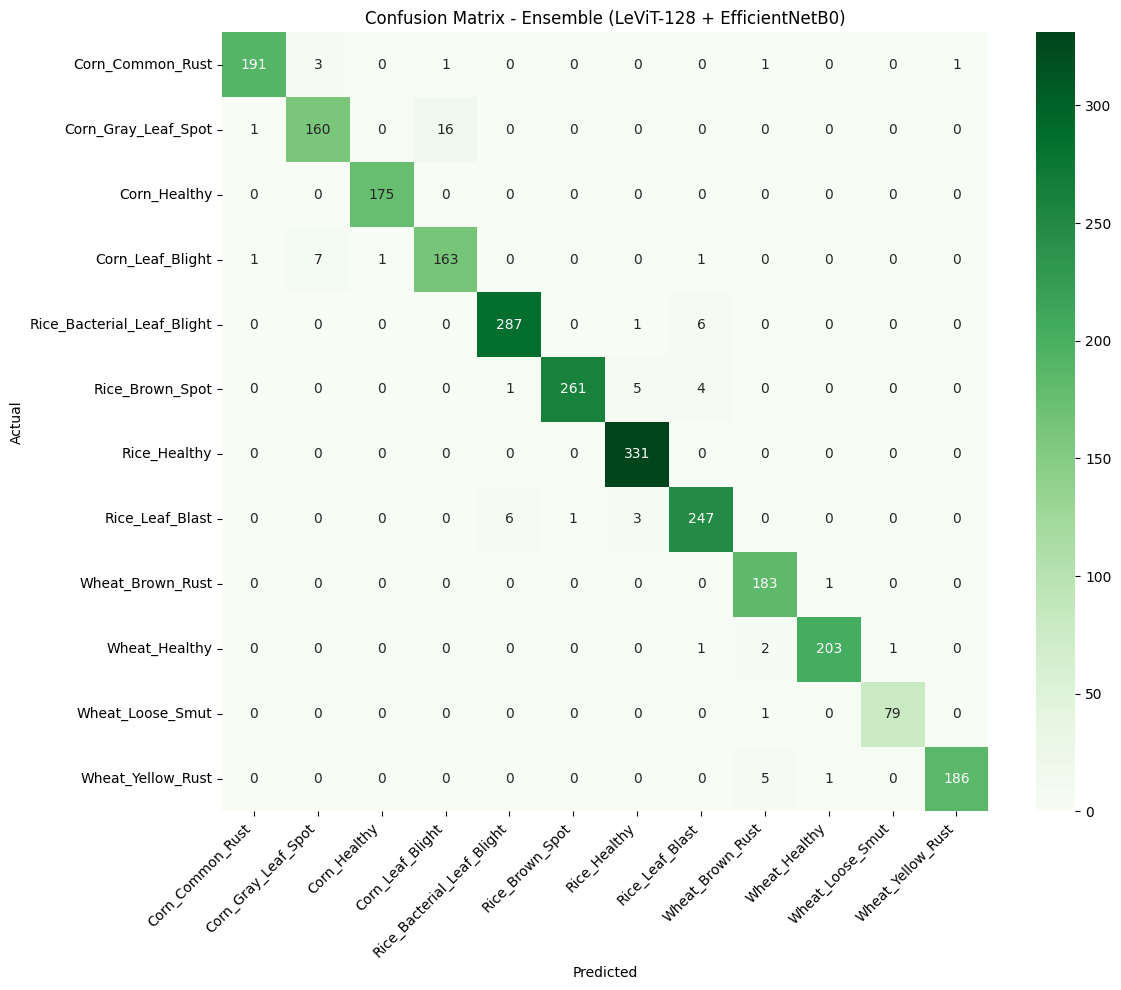

Saved report and confusion matrix to Drive: /content/drive/MyDrive/thesis_ensemble_outputs


In [17]:
output_folder = '/content/drive/MyDrive/thesis_ensemble_outputs'
os.makedirs(output_folder, exist_ok=True)

with open(f'{output_folder}/ensemble_levit_efficientnetb0_report.txt', 'w') as f:
    f.write(f"LeViT-128 accuracy: {acc_levit:.4f}\n")
    f.write(f"EfficientNetB0 accuracy: {acc_efficientnet:.4f}\n")
    f.write(f"Ensemble (simple average) accuracy: {acc_ensemble:.4f}\n")
    f.write(f"Best weighted combo (LeViT={best_w[0]:.2f}, EfficientNetB0={best_w[1]:.2f}) TEST accuracy: {weighted_test_acc:.4f}\n\n")
    f.write(report)

cm = confusion_matrix(true_labels, ensemble_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Ensemble (LeViT-128 + EfficientNetB0)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{output_folder}/ensemble_levit_efficientnetb0_confusion_matrix.png', dpi=150)
plt.show()

print("Saved report and confusion matrix to Drive:", output_folder)
